In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch.utils.data import Dataset, DataLoader

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bike+sharing+dataset (1).zip to bike+sharing+dataset (1) (1).zip


In [ ]:
import zipfile
import os

zip_file = "Bike-Sharing-Dataset.zip"  # change name if needed

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("data")

os.listdir("data")

['hour.csv', 'day.csv', 'Readme.txt']

In [ ]:
# ===============================
# 1. Load Data
# ===============================
df = pd.read_csv("data/hour.csv")

df = df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1)

target = 'cnt'

In [ ]:
# ===============================
# 2. Feature Engineering (VERY IMPORTANT)
# ===============================

# Cyclical encoding for hour
df['hour_sin'] = np.sin(2 * np.pi * df['hr'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hr'] / 24)

# Cyclical encoding for weekday
df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

# Drop original columns
df = df.drop(['hr', 'weekday'], axis=1)

In [ ]:
# ===============================
# 3. Scale Features + Target
# ===============================
X_scaler = StandardScaler()
y_scaler = StandardScaler()

X = X_scaler.fit_transform(df.drop(target, axis=1))
y = y_scaler.fit_transform(df[[target]]).flatten()

In [ ]:
# ===============================
# 4. Create Sequences
# ===============================
SEQ_LEN = 24

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X, y, SEQ_LEN)

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, shuffle=False
)

In [ ]:
# ===============================
# 5. Dataset
# ===============================
class BikeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(BikeDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(BikeDataset(X_test, y_test), batch_size=64)


In [ ]:
# ===============================
# 6. Positional Encoding
# ===============================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [ ]:
# ===============================
# 7. Transformer Model
# ===============================
class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model=128, nhead=8, num_layers=3):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            dropout=0.2,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(d_model)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = x[:, -1, :]
        x = self.norm(x)
        return self.fc(x).squeeze()

model = TransformerModel(input_dim=X_train.shape[2])

In [ ]:
# ===============================
# 8. Training Setup
# ===============================
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [ ]:
# ===============================
# 9. Training Loop
# ===============================
EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 57.0503
Epoch 2, Loss: 22.3670
Epoch 3, Loss: 18.0993
Epoch 4, Loss: 16.4254
Epoch 5, Loss: 15.6327
Epoch 6, Loss: 13.9847
Epoch 7, Loss: 13.5977
Epoch 8, Loss: 13.3522
Epoch 9, Loss: 12.7724
Epoch 10, Loss: 11.7181
Epoch 11, Loss: 12.7662
Epoch 12, Loss: 11.3058
Epoch 13, Loss: 11.0439
Epoch 14, Loss: 10.5991
Epoch 15, Loss: 10.5984
Epoch 16, Loss: 10.3523
Epoch 17, Loss: 9.9708
Epoch 18, Loss: 10.0963
Epoch 19, Loss: 10.0455
Epoch 20, Loss: 9.9070
Epoch 21, Loss: 8.9123
Epoch 22, Loss: 9.2480
Epoch 23, Loss: 9.5618
Epoch 24, Loss: 8.8057
Epoch 25, Loss: 9.0114
Epoch 26, Loss: 8.1240
Epoch 27, Loss: 8.4252
Epoch 28, Loss: 8.2165
Epoch 29, Loss: 8.0712
Epoch 30, Loss: 8.3483


In [ ]:
# ===============================
# 10. Evaluation
# ===============================
model.eval()
preds_list, actuals = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch)
        preds_list.extend(preds.numpy())
        actuals.extend(y_batch.numpy())

In [ ]:
# Inverse scaling
preds_list = y_scaler.inverse_transform(np.array(preds_list).reshape(-1,1))
actuals = y_scaler.inverse_transform(np.array(actuals).reshape(-1,1))

In [ ]:
# Metrics
rmse = np.sqrt(mean_squared_error(actuals, preds_list))
mae = mean_absolute_error(actuals, preds_list)
r2 = r2_score(actuals, preds_list)

print("\nResults:")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Results:
RMSE: 59.64429064252504
MAE: 41.84325408935547
R2: 0.9269086122512817


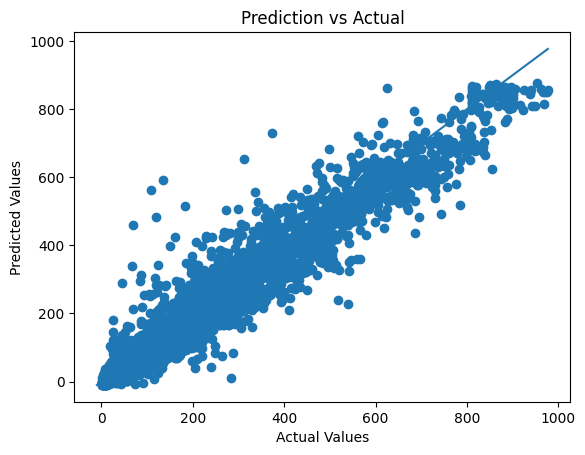

In [ ]:
import matplotlib.pyplot as plt

# Flatten arrays
actuals_flat = actuals.flatten()
preds_flat = preds_list.flatten()

plt.figure()
plt.scatter(actuals_flat, preds_flat)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Prediction vs Actual")

# Ideal line
min_val = min(min(actuals_flat), min(preds_flat))
max_val = max(max(actuals_flat), max(preds_flat))
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

“Points closer to the diagonal line indicate better predictions. The model shows strong alignment with actual values.”

Loss Curve Visualization

Modify your training loop to store loss: **bold text**

In [ ]:
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_losses.append(total_loss)
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 8.1158
Epoch 2, Loss: 7.5736
Epoch 3, Loss: 8.0755
Epoch 4, Loss: 7.7890
Epoch 5, Loss: 7.6123
Epoch 6, Loss: 7.6952
Epoch 7, Loss: 7.4948
Epoch 8, Loss: 7.9457
Epoch 9, Loss: 7.5555
Epoch 10, Loss: 7.1144
Epoch 11, Loss: 7.0536
Epoch 12, Loss: 7.1189
Epoch 13, Loss: 6.7217
Epoch 14, Loss: 6.5946
Epoch 15, Loss: 7.0022
Epoch 16, Loss: 6.7797
Epoch 17, Loss: 6.6928
Epoch 18, Loss: 6.6661
Epoch 19, Loss: 6.5990
Epoch 20, Loss: 6.7457
Epoch 21, Loss: 6.6718
Epoch 22, Loss: 7.3888
Epoch 23, Loss: 6.3287
Epoch 24, Loss: 6.4753
Epoch 25, Loss: 6.1136
Epoch 26, Loss: 6.1831
Epoch 27, Loss: 6.3858
Epoch 28, Loss: 7.0884
Epoch 29, Loss: 6.2839
Epoch 30, Loss: 6.3705


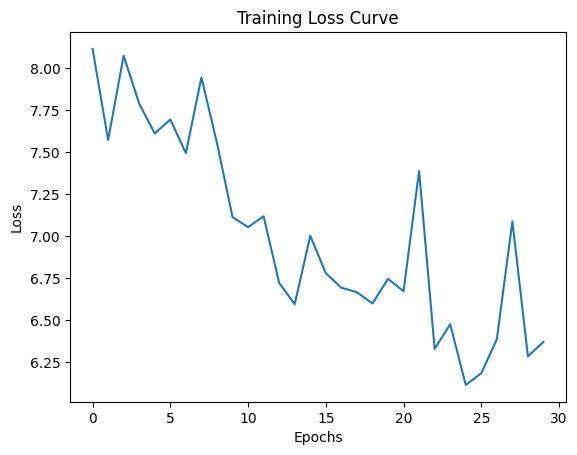

In [ ]:
plt.figure()
plt.plot(train_losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

Interpretation:

Downward curve = model is learning
Flattening = convergence

**Test Your Model (Manual Prediction)**

In [ ]:
def predict_sample(index):
    model.eval()

    X_sample = torch.tensor(X_test[index:index+1], dtype=torch.float32)

    with torch.no_grad():
        pred = model(X_sample).numpy()

    # Inverse scaling
    pred_original = y_scaler.inverse_transform(pred.reshape(-1,1))

    print("Predicted Bike Demand:", pred_original[0][0])
    print("Actual Bike Demand:", y_scaler.inverse_transform([[y_test[index]]])[0][0])

# Try any index
predict_sample(10)

Predicted Bike Demand: 0.5272203
Actual Bike Demand: 6.999999999999972


In [ ]:
predict_sample(30)

Predicted Bike Demand: 149.32295
Actual Bike Demand: 136.0


In [ ]:
predict_sample(24)

Predicted Bike Demand: 858.8303
Actual Bike Demand: 858.0


In [ ]:
predict_sample(50)

Predicted Bike Demand: 578.2354
Actual Bike Demand: 623.0


In [ ]:
import torch

torch.save(model.state_dict(), "transformer_model.pth")

In [ ]:
import joblib

joblib.dump(X_scaler, "x_scaler.pkl")
joblib.dump(y_scaler, "y_scaler.pkl")

['y_scaler.pkl']

In [ ]:
df.to_csv("hour.csv", index=False)

In [ ]:
from google.colab import files

files.download("transformer_model.pth")
files.download("x_scaler.pkl")
files.download("y_scaler.pkl")
files.download("hour.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>